# SECTION 1: Import Required Libraries and Dependencies
### Loading TensorFlow, visualization libraries, ConvNeXt backbone, and evaluation utilities



In [55]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# model + preprocessing
from tensorflow.keras.applications.convnext import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)
AUTOTUNE = tf.data.AUTOTUNE

TensorFlow Version: 2.19.0


# SECTION 2: Mount Google Drive and Access Dataset Storage
### Connecting Google Drive to locate the compressed hand gesture dataset

In [56]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# SECTION 3: Locate and Extract Dataset ZIP File
### Searching for dataset archive and extracting it into the Colab working directory

In [57]:
target_file = 'Hand gestre detection datasdet.zip'
zip_path = None

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if target_file in files:
        zip_path = os.path.join(root, target_file)
        print("ZIP Found:", zip_path)
        break

if zip_path is None:
    raise FileNotFoundError(f"{target_file} not found under /content/drive/MyDrive")

extract_path = '/content/hand_dataset'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction Complete")


ZIP Found: /content/drive/MyDrive/Hand gestre detection datasdet.zip
Extraction Complete


# SECTION 4: Define Dataset Root and Build File Metadata
### Traversing subject folders and collecting image filepaths with labels

In [58]:
dataset_root = '/content/hand_dataset/leapGestRecog'

_VALID_IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

data = []

for subject in sorted(os.listdir(dataset_root)):
    subject_path = os.path.join(dataset_root, subject)
    if not os.path.isdir(subject_path):
        continue

    for gesture in sorted(os.listdir(subject_path)):
        gesture_path = os.path.join(subject_path, gesture)
        if not os.path.isdir(gesture_path):
            continue

        for fname in sorted(os.listdir(gesture_path)):
            ext = os.path.splitext(fname)[1].lower()
            if ext not in _VALID_IMG_EXT:
                continue

            fpath = os.path.join(gesture_path, fname)

            data.append({
                'subject': subject,
                'raw_label': gesture,
                'filepath': fpath
            })

df = pd.DataFrame(data)

print("Total Samples:", len(df))
df.head()

Total Samples: 20000


,subject,raw_label,filepath
0,00,01_palm,/content/hand_dataset/leapGestRecog/00/01_palm...
1,00,01_palm,/content/hand_dataset/leapGestRecog/00/01_palm...
2,00,01_palm,/content/hand_dataset/leapGestRecog/00/01_palm...
3,00,01_palm,/content/hand_dataset/leapGestRecog/00/01_palm...
4,00,01_palm,/content/hand_dataset/leapGestRecog/00/01_palm...


# SECTION 5: Label Cleaning, Encoding, and Subject-Wise Dataset Split
### Converting raw gesture labels into clean class names and creating train-validation-test partitions

In [24]:
class_mapping = {
    '01_palm': 'palm',
    '02_l': 'l',
    '03_fist': 'fist',
    '04_fist_moved': 'fist_moved',
    '05_thumb': 'thumb',
    '06_index': 'index',
    '07_ok': 'ok',
    '08_palm_moved': 'palm_moved',
    '09_c': 'c',
    '10_down': 'down'
}
df['clean_label'] = df['label'].map(class_mapping)

df['subject'] = df['subject'].astype(str)

train_df = df[df['subject'].isin(['00','01','02','03','04','05','06','07'])].copy()
val_df   = df[df['subject'].isin(['08'])].copy()
test_df  = df[df['subject'].isin(['09'])].copy()

print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))

# encode labels
class_names = sorted(df['clean_label'].unique())
label_to_index = {label: idx for idx, label in enumerate(class_names)}
train_df['label_idx'] = train_df['clean_label'].map(label_to_index)
val_df['label_idx']   = val_df['clean_label'].map(label_to_index)
test_df['label_idx']  = test_df['clean_label'].map(label_to_index)

print("Classes:", class_names)
print("Label mapping:", label_to_index)

Train / Val / Test sizes: 16000 2000 2000
Classes: ['c', 'down', 'fist', 'fist_moved', 'index', 'l', 'ok', 'palm', 'palm_moved', 'thumb']
Label mapping: {'c': 0, 'down': 1, 'fist': 2, 'fist_moved': 3, 'index': 4, 'l': 5, 'ok': 6, 'palm': 7, 'palm_moved': 8, 'thumb': 9}


# SECTION 6: Visualize Class Distribution Across the Entire Dataset
### Checking sample balance for all gesture categories

/tmp/ipykernel_6711/1384991206.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


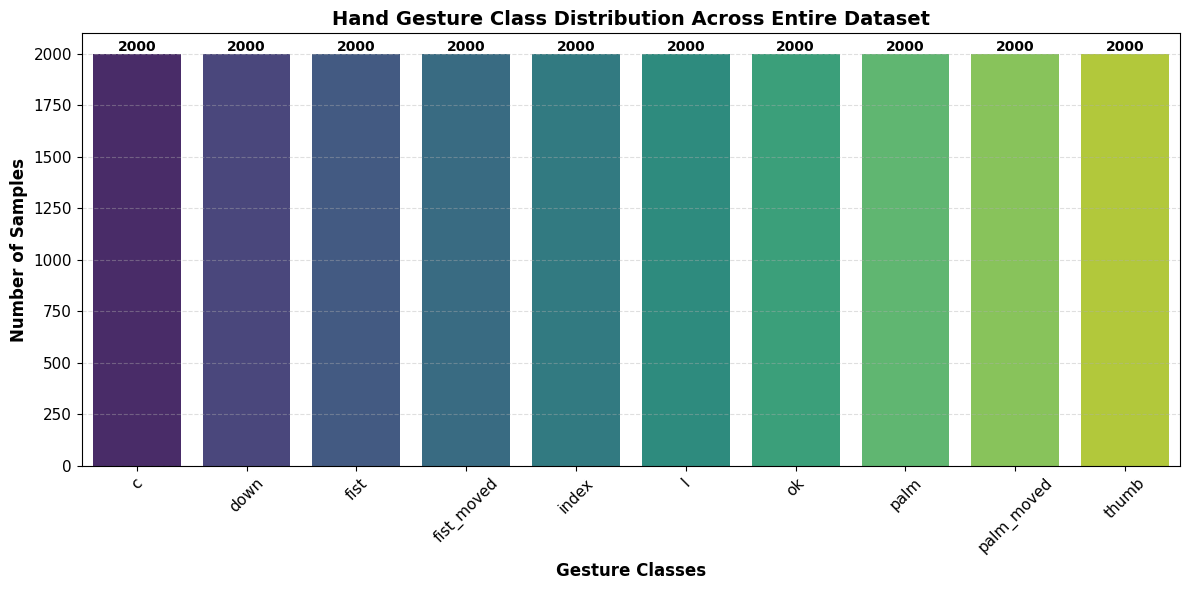

In [46]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    x='clean_label',
    order=class_names,
    palette='viridis'
)

# Add counts above bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Labels and styling
plt.xlabel('Gesture Classes', fontsize=12, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
plt.title('Hand Gesture Class Distribution Across Entire Dataset', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# SECTION 7: Build TensorFlow Input Pipeline
### Image decoding, resizing, batching, and dataset optimization using tf.data

In [26]:
IMG_SIZE = 224
BATCH_SIZE = 32

# robust loader that handles common image formats
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 3))
    return img, tf.cast(label, tf.int32)

def build_dataset(dataframe, shuffle=False, repeat=False):
    paths = dataframe['filepath'].values.astype(str)
    labels = dataframe['label_idx'].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: load_image(p, l), num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(2048)
    if repeat:
        ds = ds.repeat()
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(train_df, shuffle=True)
val_ds   = build_dataset(val_df)
test_ds  = build_dataset(test_df)

for imgs, lbls in train_ds.take(1):
    print("Batch images:", imgs.shape, "labels:", lbls.shape)
    break

Batch images: (32, 224, 224, 3) labels: (32,)


# SECTION 8: Initialize Data Augmentation and ConvNeXtTiny Backbone
### Applying augmentation and loading ImageNet pretrained ConvNeXtTiny

In [59]:
from tensorflow.keras.applications.convnext import ConvNeXtTiny, preprocess_input

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05)
], name='data_augmentation')

# Backbone model
base_model = ConvNeXtTiny(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freezing backbone initially
base_model.trainable = False

# SECTION 9: Construct Attention-Based Deep Learning Architecture
### Channel attention, spatial attention, and dense classification head

In [28]:
# Input layer
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')

# Augmentation + preprocessing
x = data_augmentation(inputs)
x = preprocess_input(x)

# Backbone forward pass
x = base_model(x, training=False)

# Channel Attention (Squeeze & Excitation)
gap = layers.GlobalAveragePooling2D(name='gap')(x)

channel = layers.Dense(256, activation='relu')(gap)
channel = layers.Dense(x.shape[-1], activation='sigmoid')(channel)
channel = layers.Reshape((1, 1, x.shape[-1]))(channel)

x = layers.Multiply()([x, channel])

# Spatial Attention
spatial = layers.Conv2D(64, (1,1), activation='relu')(x)
spatial = layers.Conv2D(1, (1,1), activation='sigmoid')(spatial)

x = layers.Multiply()([x, spatial])

# Classification Head
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(len(class_names), activation='softmax', name='predictions')(x)

# Final model
model = tf.keras.Model(inputs, outputs, name='convnext_attention')

# Summary
model.summary()

Model: "convnext_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny       │ (None, 7, 7, 768) │ 27,820,128 │ data_augmentatio… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 768)       │          0 │ convnext_tiny[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │    196,864 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 768)       │    197,376 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 1, 768) │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 7, 7, 768) │          0 │ convnext_tiny[0]… │
│ (Multiply)          │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 7, 7, 64)  │     49,216 │ multiply_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 7, 7, 1)   │         65 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_5          │ (None, 7, 7, 768) │          0 │ multiply_4[0][0], │
│ (Multiply)          │                   │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ multiply_5[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 768)       │      3,072 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 512)       │    393,728 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 512)       │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 256)       │    131,328 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 10)        │      2,570 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,794,347 (109.84 MB)

 Trainable params: 972,683 (3.71 MB)

 Non-trainable params: 27,821,664 (106.13 MB)

# SECTION 10: Compile Model with Loss Function and Evaluation Metrics
### Defining optimizer, sparse categorical loss, and top-k accuracy metrics

In [29]:
metrics = [
    tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
    tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top_3_accuracy')
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=metrics
)

# SECTION 11: Configure Training Callbacks
### Early stopping, learning rate reduction, and best model checkpointing

In [30]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        'best_hand_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# SECTION 12: Initial Transfer Learning Training Phase
### Training frozen ConvNeXt backbone on gesture dataset

In [31]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.6967 - loss: 0.9898 - top_3_accuracy: 0.8486
Epoch 1: val_accuracy improved from None to 0.84650, saving model to best_hand_model.keras

Epoch 1: finished saving model to best_hand_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 216s 400ms/step - accuracy: 0.8587 - loss: 0.4804 - top_3_accuracy: 0.9504 - val_accuracy: 0.8465 - val_loss: 0.5806 - val_top_3_accuracy: 0.9400 - learning_rate: 1.0000e-04
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9857 - loss: 0.0517 - top_3_accuracy: 0.9993
Epoch 2: val_accuracy improved from 0.84650 to 0.88550, saving model to best_hand_model.keras

Epoch 2: finished saving model to best_hand_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 197s 385ms/step - accuracy: 0.9891 - loss: 0.0414 - top_3_accuracy: 0.9995 - val_accuracy: 0.8855 - val_loss: 0.4967 - val_top_3_accuracy: 0.9495 - learning_rate: 1.0000e-04
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.9

# SECTION 13: Visualize Initial Training Accuracy Curves
### Comparing training and validation accuracy across epochs

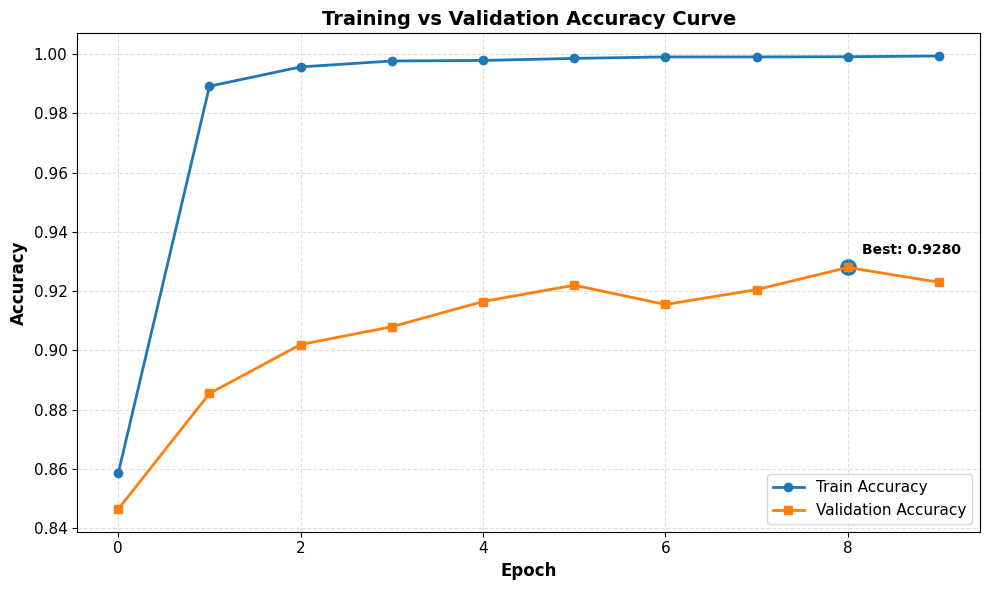

In [47]:
plt.figure(figsize=(10,6))

plt.plot(
    history.history['accuracy'],
    marker='o',
    linewidth=2,
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    marker='s',
    linewidth=2,
    label='Validation Accuracy'
)

# Highlight best validation epoch
best_epoch = np.argmax(history.history['val_accuracy'])
best_val = max(history.history['val_accuracy'])

plt.scatter(
    best_epoch,
    best_val,
    s=120
)

plt.annotate(
    f'Best: {best_val:.4f}',
    (best_epoch, best_val),
    textcoords="offset points",
    xytext=(10,10),
    fontsize=10,
    fontweight='bold'
)

# Labels
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Training vs Validation Accuracy Curve', fontsize=14, fontweight='bold')

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# SECTION 14: Visualize Initial Training Loss Curves
### Monitoring convergence behavior using loss trends

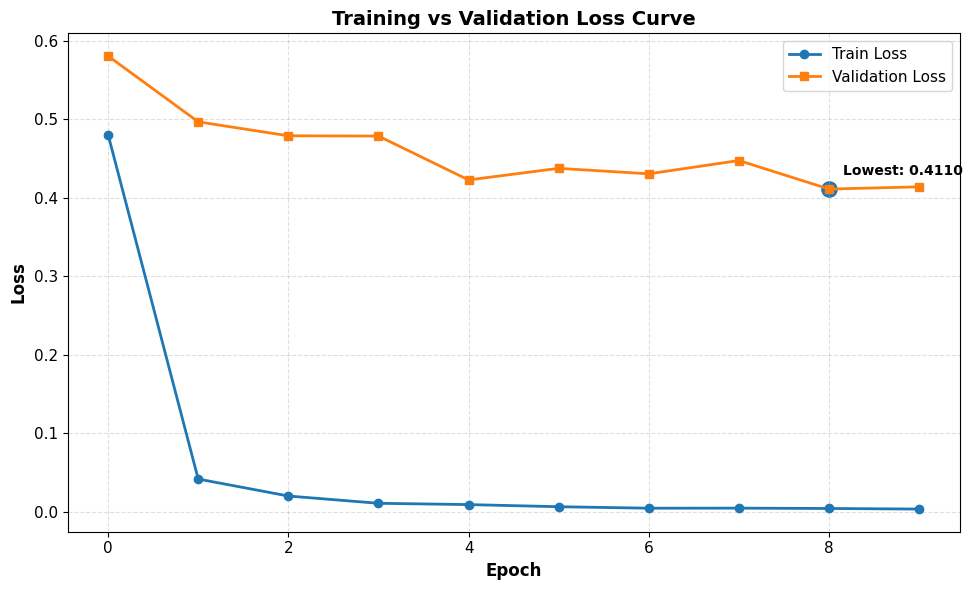

In [48]:
plt.figure(figsize=(10,6))

plt.plot(
    history.history['loss'],
    marker='o',
    linewidth=2,
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    marker='s',
    linewidth=2,
    label='Validation Loss'
)

# Highlight lowest validation loss epoch
best_epoch = np.argmin(history.history['val_loss'])
best_val_loss = min(history.history['val_loss'])

plt.scatter(
    best_epoch,
    best_val_loss,
    s=120
)

plt.annotate(
    f'Lowest: {best_val_loss:.4f}',
    (best_epoch, best_val_loss),
    textcoords="offset points",
    xytext=(10,10),
    fontsize=10,
    fontweight='bold'
)

# Labels
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.title('Training vs Validation Loss Curve', fontsize=14, fontweight='bold')

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# SECTION 15: Fine-Tuning Setup and Training Phase
### Unfreezing upper ConvNeXt layers, reducing learning rate, and refining pretrained feature representations

In [33]:
base_model.trainable = True
# freezing lower layers
if len(base_model.layers) > 30:
    for layer in base_model.layers[:-30]:
        layer.trainable = False

# recompile with lower lr
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=metrics
)

# checkpoint for fine-tuning
fine_ckpt = ModelCheckpoint(
    'best_finetuned_hand_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

fine_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks + [fine_ckpt]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.9787 - loss: 0.0017 - top_3_accuracy: 0.9915
Epoch 1: val_accuracy improved from 0.92800 to 0.93100, saving model to best_hand_model.keras

Epoch 1: finished saving model to best_hand_model.keras

Epoch 1: val_accuracy improved from None to 0.93100, saving model to best_finetuned_hand_model.keras

Epoch 1: finished saving model to best_finetuned_hand_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 387s 727ms/step - accuracy: 0.9911 - loss: 0.0019 - top_3_accuracy: 0.9966 - val_accuracy: 0.9310 - val_loss: 0.4188 - val_top_3_accuracy: 0.9705 - learning_rate: 1.0000e-05
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.9995 - loss: 0.0028 - top_3_accuracy: 1.0000
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 2: val_accuracy did not improve from 0.93100

Epoch 2: val_accuracy did not improve from 0.93100
500/500 ━━━━━━━━━━━━━━━━━━━━ 355s 703ms/step - accuracy: 0.9996 - loss

# SECTION 16: Visualize Fine-Tuning Accuracy Curves
### Accuracy progression during backbone fine-tuning

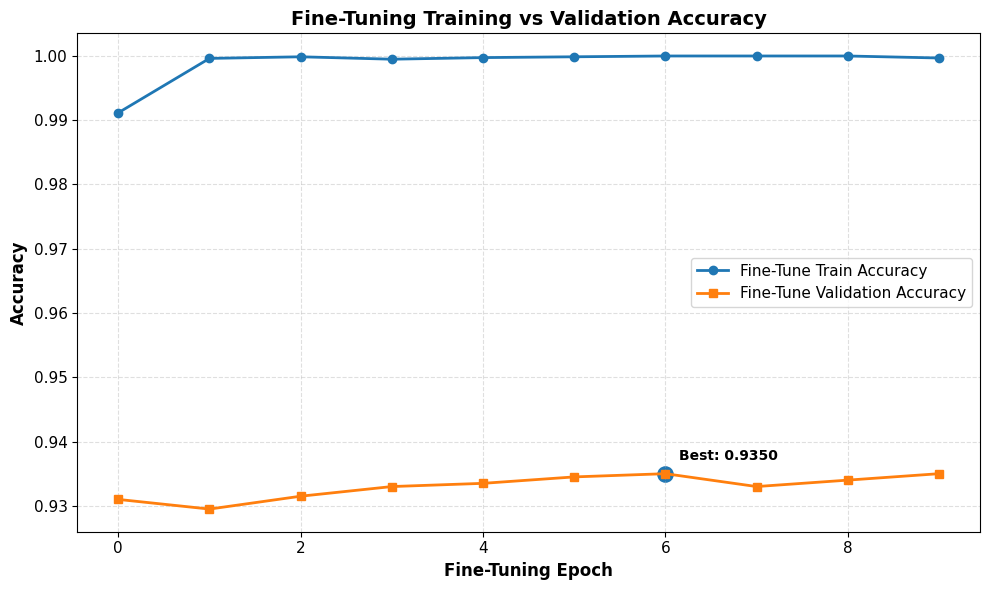

In [49]:
plt.figure(figsize=(10,6))

plt.plot(
    fine_history.history['accuracy'],
    marker='o',
    linewidth=2,
    label='Fine-Tune Train Accuracy'
)

plt.plot(
    fine_history.history['val_accuracy'],
    marker='s',
    linewidth=2,
    label='Fine-Tune Validation Accuracy'
)

# Highlight best validation epoch
best_epoch = np.argmax(fine_history.history['val_accuracy'])
best_val = max(fine_history.history['val_accuracy'])

plt.scatter(
    best_epoch,
    best_val,
    s=120
)

plt.annotate(
    f'Best: {best_val:.4f}',
    (best_epoch, best_val),
    textcoords="offset points",
    xytext=(10,10),
    fontsize=10,
    fontweight='bold'
)

# Labels
plt.xlabel('Fine-Tuning Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Fine-Tuning Training vs Validation Accuracy', fontsize=14, fontweight='bold')

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# SECTION 17: Visualize Fine-Tuning Loss Curves
### Loss stabilization during fine-tuning stage

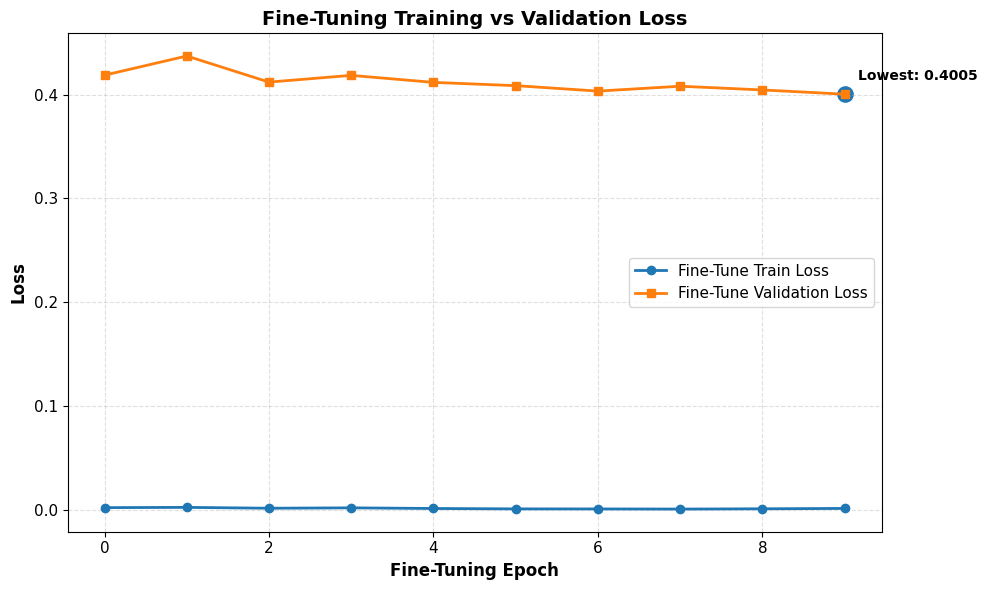

In [50]:
plt.figure(figsize=(10,6))

plt.plot(
    fine_history.history['loss'],
    marker='o',
    linewidth=2,
    label='Fine-Tune Train Loss'
)

plt.plot(
    fine_history.history['val_loss'],
    marker='s',
    linewidth=2,
    label='Fine-Tune Validation Loss'
)

# Highlight lowest validation loss epoch
best_epoch = np.argmin(fine_history.history['val_loss'])
best_val_loss = min(fine_history.history['val_loss'])

plt.scatter(
    best_epoch,
    best_val_loss,
    s=120
)

plt.annotate(
    f'Lowest: {best_val_loss:.4f}',
    (best_epoch, best_val_loss),
    textcoords="offset points",
    xytext=(10,10),
    fontsize=10,
    fontweight='bold'
)

# Labels
plt.xlabel('Fine-Tuning Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.title('Fine-Tuning Training vs Validation Loss', fontsize=14, fontweight='bold')

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# SECTION 18: Classification Report
### Precision, recall, f1-score, and class-wise performance analysis

In [39]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           c       1.00      1.00      1.00       200
        down       1.00      1.00      1.00       200
        fist       1.00      1.00      1.00       200
  fist_moved       1.00      1.00      1.00       200
       index       1.00      1.00      1.00       200
           l       0.99      1.00      1.00       200
          ok       1.00      1.00      1.00       200
        palm       1.00      0.99      0.99       200
  palm_moved       1.00      1.00      1.00       200
       thumb       1.00      1.00      1.00       200

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



# SECTION 19: Confusion Matrix Visualization
### Detailed class-level prediction analysis using confusion matrix

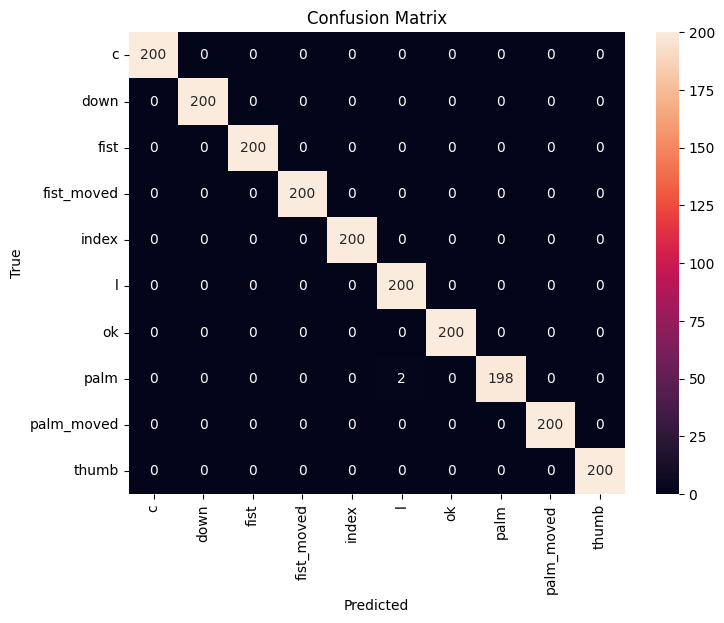

In [52]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

plt.show()

# SECTION 20: Final Model Performance Summary
### Consolidated interpretation of training, validation, and test results

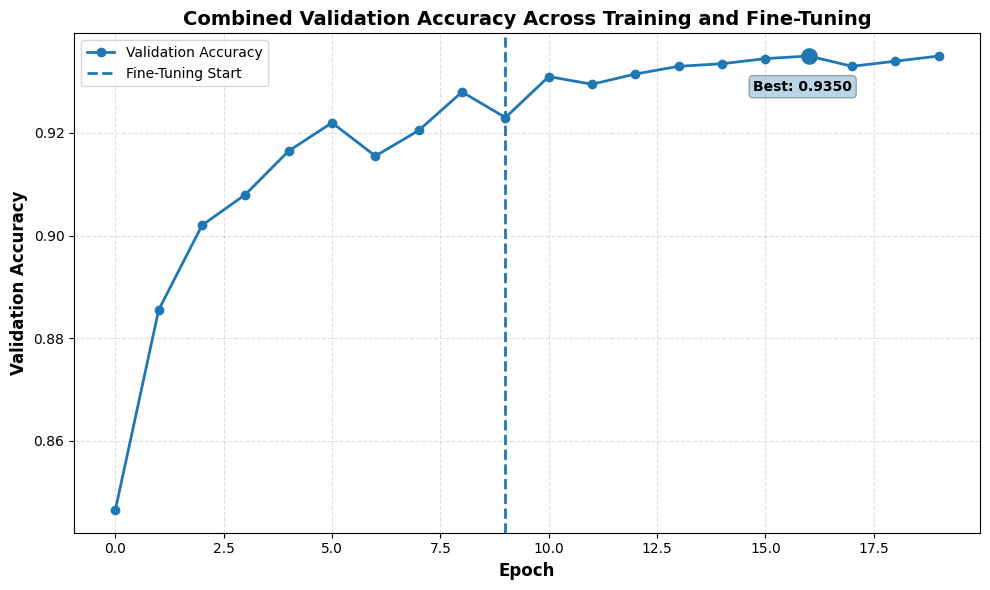

In [54]:
all_val_acc = history.history['val_accuracy'] + fine_history.history['val_accuracy']

plt.figure(figsize=(10,6))

plt.plot(
    all_val_acc,
    marker='o',
    linewidth=2,
    label='Validation Accuracy'
)

freeze_epochs = len(history.history['val_accuracy'])

plt.axvline(
    x=freeze_epochs-1,
    linestyle='--',
    linewidth=2,
    label='Fine-Tuning Start'
)

best_epoch = np.argmax(all_val_acc)
best_acc = max(all_val_acc)

plt.scatter(best_epoch, best_acc, s=120)

plt.annotate(
    f'Best: {best_acc:.4f}',
    (best_epoch, best_acc),
    textcoords="offset points",
    xytext=(-40, -25),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', alpha=0.3)
)

plt.title('Combined Validation Accuracy Across Training and Fine-Tuning', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Validation Accuracy', fontsize=12, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()